In [12]:
import sys, pandas as pd, numpy as np
import matplotlib.pyplot as plt

print("python:", sys.version)
print("pandas:", pd.__version__)



python: 3.13.11 | packaged by Anaconda, Inc. | (main, Dec 10 2025, 21:21:08) [Clang 20.1.8 ]
pandas: 2.2.3


In [10]:
from pandas_datareader import data as pdr
import datetime as dt

start = dt.datetime(1990, 1, 1)
end = dt.datetime.today()

series = {
    "DGS2": "2Y",
    "DGS10": "10Y",
    "FEDFUNDS": "FFR",
    "USREC": "REC"
}

df_list = []
for fred_code, colname in series.items():
    s = pdr.DataReader(fred_code, "fred", start, end)
    s.columns = [colname]
    df_list.append(s)

df = pd.concat(df_list, axis=1)
df = df.dropna()
df.head()


,2Y,10Y,FFR,REC
DATE,,,,
1990-02-01,8.28,8.42,8.24,0.0
1990-03-01,8.53,8.59,8.28,0.0
1990-05-01,9.02,9.08,8.18,0.0
1990-06-01,8.33,8.44,8.29,0.0
1990-08-01,7.85,8.29,8.13,1.0


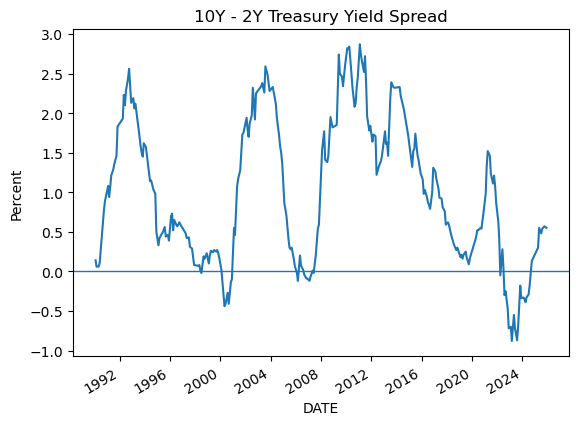

In [11]:
df["SPREAD"] = df["10Y"] - df["2Y"]

plt.figure()
df["SPREAD"].plot()
plt.axhline(0, linewidth=1)
plt.title("10Y - 2Y Treasury Yield Spread")
plt.ylabel("Percent")
plt.show()



In [15]:
df2 = df.copy()


df2["SPREAD_LAG12"] = df2["SPREAD"].shift(12)

df2 = df2.dropna()

X = sm.add_constant(df2["SPREAD_LAG12"])
y = df2["REC"]

logit = sm.Logit(y, X)
res = logit.fit()

print(res.summary())



Optimization terminated successfully.
         Current function value: 0.177969
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                    REC   No. Observations:                  265
Model:                          Logit   Df Residuals:                      263
Method:                           MLE   Df Model:                            1
Date:                Wed, 18 Feb 2026   Pseudo R-squ.:                  0.2194
Time:                        16:06:40   Log-Likelihood:                -47.162
converged:                       True   LL-Null:                       -60.421
Covariance Type:            nonrobust   LLR p-value:                 2.610e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.8146      0.280     -6.473      0.000      -2.364      -1.265
SPREAD_LAG12    -2.0223

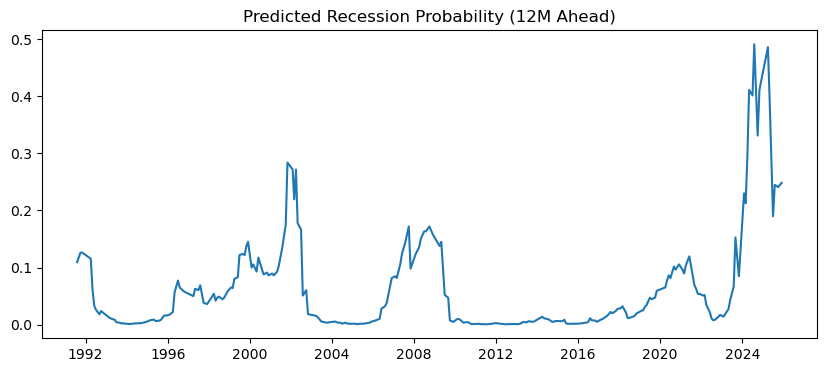

In [16]:
df2["pred_prob"] = res.predict(X)

plt.figure(figsize=(10,4))
plt.plot(df2.index, df2["pred_prob"])
plt.title("Predicted Recession Probability (12M Ahead)")
plt.show()


In [17]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y, df2["pred_prob"])


np.float64(0.8888052208835342)

In [20]:
df2["d_yield"] = df2["10Y"].diff()


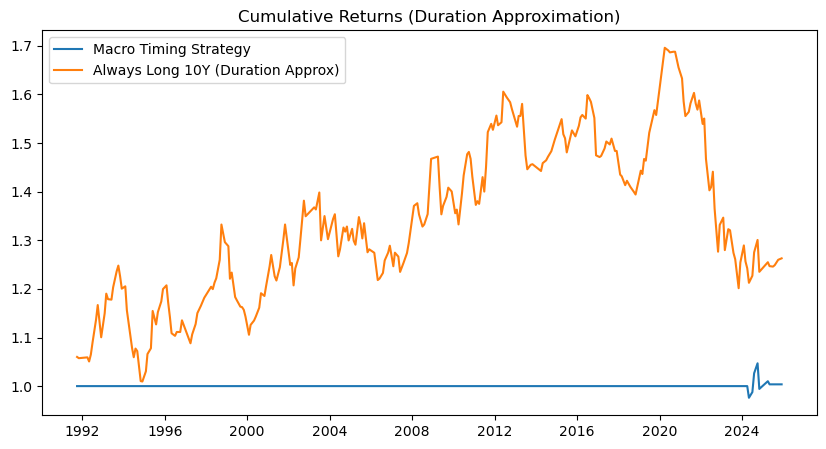

In [21]:
duration = 8  # 10Y duration rough

df2 = df2.copy()
df2["d_yield"] = df2["10Y"].diff()
df2["bond_return"] = -duration * df2["d_yield"] / 100  # yield in percent

df2["signal"] = (df2["pred_prob"] > 0.3).astype(int)
df2["strategy_return"] = df2["signal"] * df2["bond_return"]

df2 = df2.dropna()

df2["cum_strategy"] = (1 + df2["strategy_return"]).cumprod()
df2["cum_bond"] = (1 + df2["bond_return"]).cumprod()

plt.figure(figsize=(10,5))
plt.plot(df2.index, df2["cum_strategy"], label="Macro Timing Strategy")
plt.plot(df2.index, df2["cum_bond"], label="Always Long 10Y (Duration Approx)")
plt.title("Cumulative Returns (Duration Approximation)")
plt.legend()
plt.show()


In [22]:
def perf_stats(r):
    r = r.dropna()
    ann_ret = (1 + r).prod() ** (12 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan
    max_dd = ( (1+r).cumprod() / (1+r).cumprod().cummax() - 1 ).min()
    return ann_ret, ann_vol, sharpe, max_dd

print("Strategy (ann_ret, ann_vol, sharpe, maxDD):", perf_stats(df2["strategy_return"]))
print("BuyHold  (ann_ret, ann_vol, sharpe, maxDD):", perf_stats(df2["bond_return"]))


Strategy (ann_ret, ann_vol, sharpe, maxDD): (np.float64(0.0001649244000496708), np.float64(0.015832206932601754), np.float64(0.010417018976050503), -0.0504)
BuyHold  (ann_ret, ann_vol, sharpe, maxDD): (np.float64(0.010664167392295143), np.float64(0.09316970767330705), np.float64(0.11445959914018713), -0.29162344068848156)


In [23]:
df2["signal"].value_counts(dropna=False)
df2["pred_prob"].describe()
df2["pred_prob"].quantile([0.5,0.7,0.8,0.9,0.95,0.99])


0.50    0.021955
0.70    0.066627
0.80    0.100583
0.90    0.151927
0.95    0.239350
0.99    0.411310
Name: pred_prob, dtype: float64

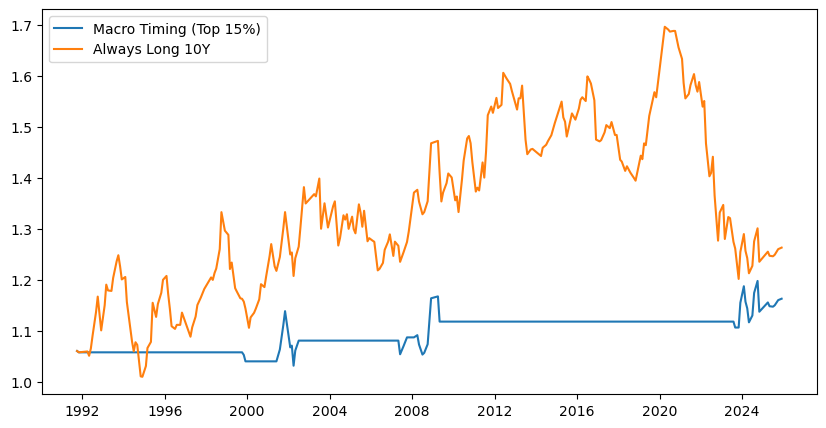

Strategy Q85: (np.float64(0.006872577452772255), np.float64(0.03896674608406791), np.float64(0.176370319398627), -0.0940137717759999)


In [24]:
q85 = df2["pred_prob"].quantile(0.85)

df2["signal_q85"] = (df2["pred_prob"] > q85).astype(int)
df2["strategy_return_q85"] = df2["signal_q85"] * df2["bond_return"]
df2["cum_strategy_q85"] = (1 + df2["strategy_return_q85"]).cumprod()

plt.figure(figsize=(10,5))
plt.plot(df2.index, df2["cum_strategy_q85"], label="Macro Timing (Top 15%)")
plt.plot(df2.index, df2["cum_bond"], label="Always Long 10Y")
plt.legend()
plt.show()

print("Strategy Q85:", perf_stats(df2["strategy_return_q85"]))


In [27]:
import numpy as np


df2 = df2.sort_index()


window = 60

df2["spread"] = df2["SPREAD"] 
df2["mu"] = df2["spread"].rolling(window).mean()
df2["sigma"] = df2["spread"].rolling(window).std()

df2["z"] = (df2["spread"] - df2["mu"]) / df2["sigma"]


df2["z_lag1"] = df2["z"].shift(1)




In [28]:
z_entry = -1.0
z_exit  =  1.0

df2["position"] = 0
df2.loc[df2["z_lag1"] < z_entry, "position"] = 1
df2.loc[df2["z_lag1"] > z_exit, "position"]  = 0


In [29]:
df2["strategy_return_z"] = df2["position"] * df2["bond_return"]
df2["cum_strategy_z"] = (1 + df2["strategy_return_z"]).cumprod()

df2["cum_bond"] = (1 + df2["bond_return"]).cumprod()


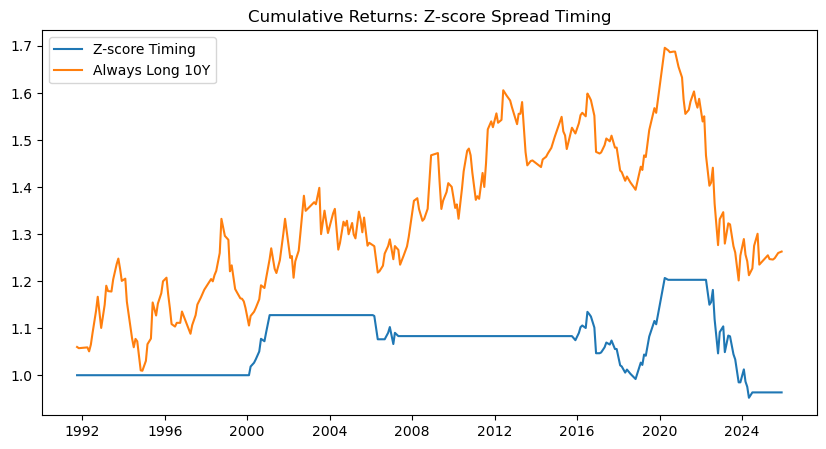

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df2.index, df2["cum_strategy_z"], label="Z-score Timing")
plt.plot(df2.index, df2["cum_bond"], label="Always Long 10Y")
plt.legend()
plt.title("Cumulative Returns: Z-score Spread Timing")
plt.show()


In [31]:
print("Z-score Strategy:", perf_stats(df2["strategy_return_z"]))
print("Buy&Hold 10Y:", perf_stats(df2["bond_return"]))


Z-score Strategy: (np.float64(-0.0016911527057825726), np.float64(0.04561713433612144), np.float64(-0.037072751947143934), -0.21101412740880066)
Buy&Hold 10Y: (np.float64(0.010664167392295143), np.float64(0.09316970767330705), np.float64(0.11445959914018713), -0.29162344068848156)


In [32]:
df2["pos_z"] = 0
df2.loc[df2["z_lag1"] < -1, "pos_z"] = 1     # long duration
df2.loc[df2["z_lag1"] >  1, "pos_z"] = -1    # short duration

df2["strategy_return_z"] = df2["pos_z"] * df2["bond_return"]
df2["cum_strategy_z"] = (1 + df2["strategy_return_z"]).cumprod()


In [33]:
df2["z"].describe()
df2["z"].quantile([0.01,0.05,0.1,0.5,0.9,0.95,0.99])


0.01   -2.493513
0.05   -1.957905
0.10   -1.799556
0.50   -0.350684
0.90    1.526889
0.95    2.263815
0.99    2.701011
Name: z, dtype: float64

In [34]:
df2["pos_z"].value_counts()


pos_z
 0    157
 1     68
-1     39
Name: count, dtype: int64

In [35]:
df2["pos_z"] = - np.tanh(df2["z_lag1"])

df2["strategy_return_z"] = df2["pos_z"] * df2["bond_return"]
df2["cum_strategy_z"] = (1 + df2["strategy_return_z"]).cumprod()

print("Continuous Z Strategy:", perf_stats(df2["strategy_return_z"]))


Continuous Z Strategy: (np.float64(-0.018383839687173498), np.float64(0.07277964028080194), np.float64(-0.25259591303617435), -0.34438419852354096)


In [36]:
df2["d_yield_lag1"] = df2["d_yield"].shift(1)

df2["pos_dy"] = - np.tanh(df2["d_yield_lag1"] * 5)

df2["strategy_return_dy"] = df2["pos_dy"] * df2["bond_return"]

df2["cum_strategy_dy"] = (1 + df2["strategy_return_dy"]).cumprod()

print("ΔYield Strategy:", perf_stats(df2["strategy_return_dy"]))


ΔYield Strategy: (np.float64(0.005679748281302022), np.float64(0.06954564340631836), np.float64(0.08166936134472523), -0.31299540065239817)


In [37]:
# ==========================================
# Regime Analysis: High Recession Probability
# ==========================================

# 定义高衰退 regime（比如 top 15%）
q85 = df2["pred_prob"].quantile(0.85)

df2["high_regime"] = (df2["pred_prob"] > q85).astype(int)

# 分组统计 bond return
high_ret = df2[df2["high_regime"] == 1]["bond_return"]
low_ret  = df2[df2["high_regime"] == 0]["bond_return"]

print("High Regime Mean:", high_ret.mean())
print("Low Regime Mean :", low_ret.mean())

print("High Regime Std :", high_ret.std())
print("Low Regime Std  :", low_ret.std())

print("High Regime 5% quantile:", high_ret.quantile(0.05))
print("Low Regime 5% quantile :", low_ret.quantile(0.05))


High Regime Mean: 0.004287179487179484
Low Regime Mean : 0.0007182222222222223
High Regime Std : 0.02932014916569347
Low Regime Std  : 0.026487768006539434
High Regime 5% quantile: -0.04319999999999999
Low Regime 5% quantile : -0.04911999999999997


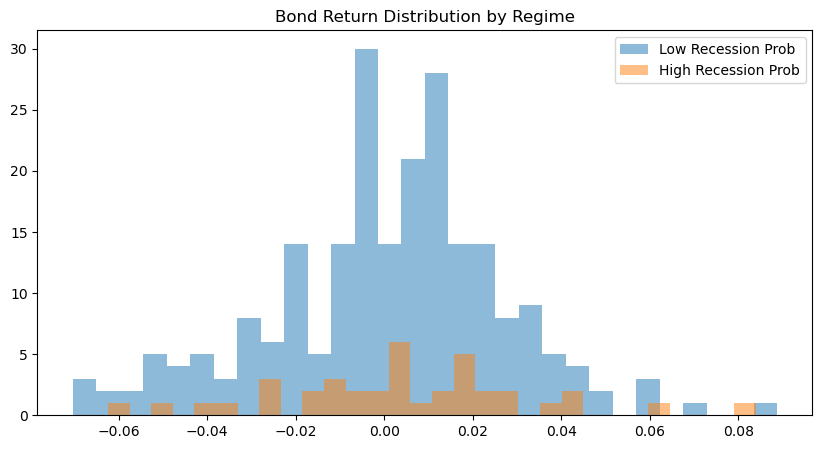

In [38]:
plt.figure(figsize=(10,5))
plt.hist(low_ret, bins=30, alpha=0.5, label="Low Recession Prob")
plt.hist(high_ret, bins=30, alpha=0.5, label="High Recession Prob")
plt.legend()
plt.title("Bond Return Distribution by Regime")
plt.show()
